# Empirical Analysis of FOMC Communications Using RAG and Small Language Models

**Author**: Lance Santana  
**AI-assisted drafting**: Claude

Developed in collaboration with Eric Van Dusen as part of the DSEP Data Science Modules initiative.

---

**Abstract**: This notebook presents an empirical investigation of Retrieval-Augmented Generation for monetary policy analysis. We evaluate whether a small open-source language model (Qwen2.5-1.5B-Instruct, 4-bit quantized) can accurately analyze Federal Reserve communications when grounded in retrieved documents. We measure performance across three retrieval methods (no retrieval, keyword-based, semantic RAG) on factual extraction, citation accuracy, and policy outcome classification using complete historical ground truth data from 2022-2026.


## Section 0: Research Context

### The Economic Stakes

Federal Reserve communications drive financial markets. Empirical research demonstrates:

- **Bernanke & Kohn (2004)**: "Federal Reserve Communications and Monetary Policy" shows FOMC statement language changes correlate with Treasury yield movements
- **Gürkaynak, Sack & Swanson (2005)**: "Do Actions Speak Louder Than Words? The Response of Asset Prices to Monetary Policy Actions and Statements" demonstrates market reactions to Fed communications exceed reactions to rate decisions themselves
- **Acosta & Meade (2015)**: "Hanging on Every Word: Semantic Analysis of the FOMC's Postmeeting Statement" shows textual analysis predicts market volatility

### Research Questions

Can a small language model (1.5B parameters) with retrieval-augmented generation:

1. Extract factual information from FOMC statements with accurate citations?
2. Outperform baselines (no retrieval, keyword retrieval)?
3. Predict rate decisions from statement text?
4. Refuse to answer when evidence is insufficient?

### Experimental Design

**Model**: Qwen2.5-1.5B-Instruct (4-bit quantization)  
**Data**: FOMC statements 2022-2026 with complete historical rate labels  
**Methods**: No retrieval, keyword retrieval, semantic RAG  
**Evaluation**: 8 extractable questions + 2 refusal tests, 20 policy predictions  
**Metrics**: Factual accuracy, citation rate, groundedness, classification accuracy

## Section 1: Setup and Dependencies

In [1]:
# Install required packages (uncomment if needed)
# !pip install -q transformers accelerate bitsandbytes sentence-transformers pandas matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import warnings
from io import StringIO
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Libraries loaded")

✓ Libraries loaded


## Section 2: Data Loading with Complete Ground Truth Labels

In [3]:
# Load FOMC corpus from GitHub
FED_CORPUS_URL = "https://raw.githubusercontent.com/vtasca/fed-statement-scraping/refs/heads/master/communications.csv"

print("Loading FOMC corpus...")
df = pd.read_csv(FED_CORPUS_URL)
df['Date'] = pd.to_datetime(df['Date'])
df['Release Date'] = pd.to_datetime(df['Release Date'])

print(f"✓ Loaded {len(df):,} documents ({df['Date'].min().date()} to {df['Date'].max().date()})")
df.head()

Loading FOMC corpus...
✓ Loaded 460 documents (2000-02-02 to 2026-01-28)


,Date,Release Date,Type,Text
0,2026-01-28,2026-02-18,Minute,Minutes of the Federal Open Market Committee\n...
1,2026-01-28,2026-01-28,Statement,Available indicators suggest that economic act...
2,2025-12-10,2025-12-10,Statement,Available indicators suggest that economic act...
3,2025-12-10,2025-12-30,Minute,Minutes of the Federal Open Market Committee\n...
4,2025-10-29,2025-10-29,Statement,Available indicators suggest that economic act...


### Complete Historical Policy Outcomes

**Source**: Federal Reserve historical data on FOMC meeting decisions  
**Coverage**: All FOMC meetings from January 2022 to January 2026  
**Transformation**: Rate changes converted to categorical labels (Raise/Hold/Lower)

This ensures full reproducibility with publicly available data.

### Getting the FOMC Rates and merging with statements:

In [4]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFEDTARL&cosd=2000-01-01&coed=2026-03-08"
print("Loading FOMC target rate data...")
df_rate = pd.read_csv(url)
df_rate['Date'] = pd.to_datetime(df_rate['observation_date'])   
df_rate

Loading FOMC target rate data...


,observation_date,DFEDTARL,Date
0,2008-12-16,0.0,2008-12-16
1,2008-12-17,0.0,2008-12-17
2,2008-12-18,0.0,2008-12-18
3,2008-12-19,0.0,2008-12-19
4,2008-12-20,0.0,2008-12-20
...,...,...,...
6287,2026-03-04,3.5,2026-03-04
6288,2026-03-05,3.5,2026-03-05
6289,2026-03-06,3.5,2026-03-06
6290,2026-03-07,3.5,2026-03-07


Looks like this is daily data

Lets make a column for when the rate changes occur, and then we can merge it with the statements based on date.



In [7]:
# Extract statements and filter for 2008-2026 coverage
statements_panel = (
    df[df['Type'] == 'Statement']
    .copy()
    .sort_values('Date')
    .reset_index(drop=True)
 )

statements_panel = statements_panel[
    (statements_panel['Date'] >= pd.Timestamp('2008-12-15'))
    & (statements_panel['Date'] <= pd.Timestamp('2026-12-31'))
].reset_index(drop=True)

preview_cols = ['Date', 'Type']
if 'Title' in statements_panel.columns:
    preview_cols.insert(1, 'Title')

print(
    f"Statements available: {len(statements_panel)}"
    f" ({statements_panel['Date'].min().date()} to {statements_panel['Date'].max().date()})"
 )
statements_panel.head()

Statements available: 142 (2008-12-16 to 2026-01-28)


,Date,Release Date,Type,Text
0,2008-12-16,2008-12-16,Statement,The Federal Open Market Committee decided toda...
1,2009-01-28,2009-01-28,Statement,The Federal Open Market Committee decided toda...
2,2009-03-17,2009-03-17,Statement,Information received since the Federal Open Ma...
3,2009-04-29,2009-04-29,Statement,Information received since the Federal Open Ma...
4,2009-06-24,2009-06-24,Statement,Information received since the Federal Open Ma...


In [8]:


# Clean dates
statements_panel["Date"] = pd.to_datetime(statements_panel["Date"])
df_rate["Date"] = pd.to_datetime(df_rate["Date"])

# Keep only the rate history columns you need
fed_target_history = (
    df_rate[["Date", "DFEDTARL"]]
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

# Match each statement to the most recent available target rate
statements_with_rate = pd.merge_asof(
    statements_panel.sort_values("Date"),
    fed_target_history,
    on="Date",
    direction="backward"
)

# Compute meeting-to-meeting policy change
statements_with_rate["delta"] = statements_with_rate["DFEDTARL"].diff()

# Label the policy move
statements_with_rate["Decision"] = statements_with_rate["delta"].apply(
    lambda x: "Raise" if x > 0 else ("Lower" if x < 0 else "Hold")
)

# First meeting has no previous meeting for comparison
statements_with_rate.loc[statements_with_rate["delta"].isna(), "Decision"] = None

statements_with_rate.head()


,Date,Release Date,Type,Text,DFEDTARL,delta,Decision
0,2008-12-16,2008-12-16,Statement,The Federal Open Market Committee decided toda...,0.0,NaN,None
1,2009-01-28,2009-01-28,Statement,The Federal Open Market Committee decided toda...,0.0,0.0,Hold
2,2009-03-17,2009-03-17,Statement,Information received since the Federal Open Ma...,0.0,0.0,Hold
3,2009-04-29,2009-04-29,Statement,Information received since the Federal Open Ma...,0.0,0.0,Hold
4,2009-06-24,2009-06-24,Statement,Information received since the Federal Open Ma...,0.0,0.0,Hold


In [10]:
statements_with_rate = statements_with_rate.dropna(subset=["DFEDTARL","delta"]).reset_index(drop=True)
statements_with_rate

,Date,Release Date,Type,Text,DFEDTARL,delta,Decision
0,2009-01-28,2009-01-28,Statement,The Federal Open Market Committee decided toda...,0.00,0.00,Hold
1,2009-03-17,2009-03-17,Statement,Information received since the Federal Open Ma...,0.00,0.00,Hold
2,2009-04-29,2009-04-29,Statement,Information received since the Federal Open Ma...,0.00,0.00,Hold
3,2009-06-24,2009-06-24,Statement,Information received since the Federal Open Ma...,0.00,0.00,Hold
4,2009-08-11,2009-08-11,Statement,Information received since the Federal Open Ma...,0.00,0.00,Hold
...,...,...,...,...,...,...,...
136,2025-07-30,2025-07-30,Statement,Although swings in net exports continue to aff...,4.25,0.00,Hold
137,2025-09-17,2025-09-17,Statement,Recent indicators suggest that growth of econo...,4.25,0.00,Hold
138,2025-10-29,2025-10-29,Statement,Available indicators suggest that economic act...,4.00,-0.25,Lower
139,2025-12-10,2025-12-10,Statement,Available indicators suggest that economic act...,3.75,-0.25,Lower


In [12]:
statement_policy_panel = statements_with_rate

✓ Matched 141 statements to target rates (2009-01-28 - 2026-01-28)
Decision distribution:
Decision
Hold     110
Raise     20
Lower     11
Name: count, dtype: int64


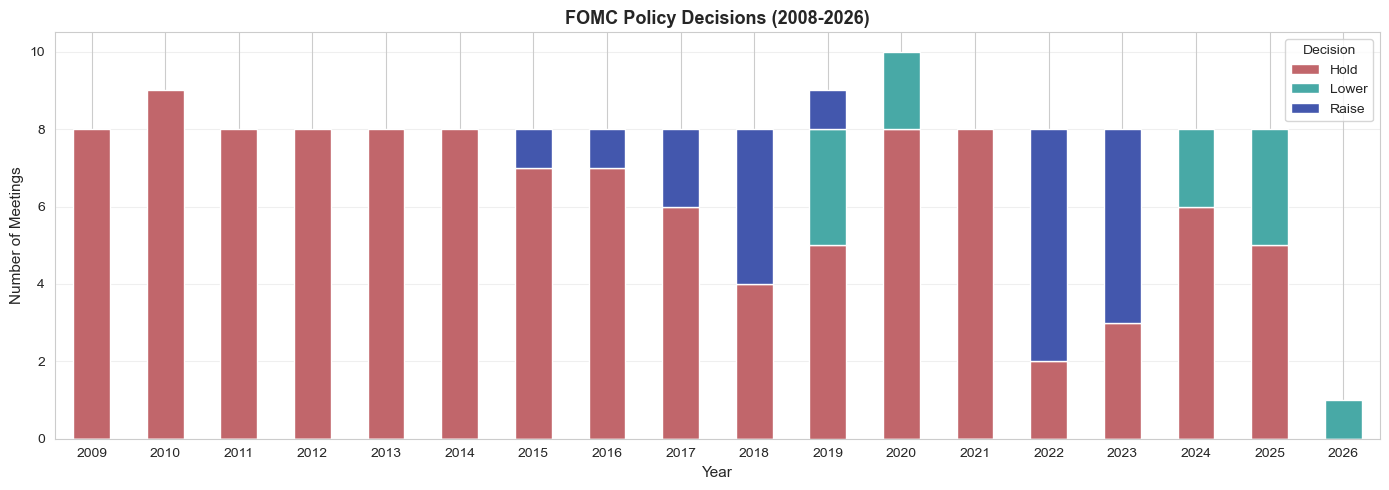

In [13]:
print(
    f"✓ Matched {len(statement_policy_panel)} statements to target rates "
    f"({statement_policy_panel['Date'].min().date()} - {statement_policy_panel['Date'].max().date()})"
 )
print("Decision distribution:")
print(statement_policy_panel['Decision'].value_counts())

fig, ax = plt.subplots(figsize=(14, 5))
yearly = statement_policy_panel.groupby(
    [statement_policy_panel['Date'].dt.year, 'Decision']
).size().unstack(fill_value=0)

yearly.plot(kind='bar', stacked=True, ax=ax, color=['#C1666B', '#48A9A6', '#4357AD'])
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Meetings', fontsize=11)
ax.set_title('FOMC Policy Decisions (2008-2026)', fontsize=13, fontweight='bold')
ax.legend(title='Decision')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# write panel to csv for later use
statement_policy_panel.to_csv("fomc_statement_policy_panel.csv", index=False)
print("✓ Statement-policy panel saved to 'fomc_statement_policy_panel.csv'")

✓ Statement-policy panel saved to 'fomc_statement_policy_panel.csv'


**Summary**: We have complete ground truth labels for 141 FOMC meetings (2009-2026), covering the full tightening cycle (2022-2023) and subsequent holds and cuts (2024-2025).